In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Read the data file
This block defines a function to load a tab-delimited file (such as a BED file) into a pandas DataFrame.

In [17]:
def load_tabular_data(file_path):
    """
    Loads a tab-delimited file into a pandas DataFrame.
    """
    return pd.read_csv(file_path, sep='\t', header=None)

# Specify file path
file_path = 'mapped.bed.gz'

# Load the data
df = load_tabular_data(file_path)

# Display basic information
print(f"Loaded data with {df.shape[0]} rows and {df.shape[1]} columns.\n")
print("Preview of the first few rows:")
display(df.head())


Loaded data with 4336134 rows and 13 columns.

Preview of the first few rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90838,91006,IH02_00.pairs@15152,168,+
1,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90846,90998,IH02_04.pairs@4163,152,+
2,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90851,91000,IH02_04.pairs@4164,149,+
3,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90850,91014,IH02_00.pairs@15153,164,+
4,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90900,90965,IH02_00.pairs@15164,65,+


### Step 2: Calculate X, Y, Z values according to the problem statement
In this step, we calculate the key components required for generating a V-plot:
- X: Difference between centers (C2 - C1)
- Y: Fragment size (Column10 - Column9)
- Z: Counter of Y at X (frequency of each Y value at each X position)

In [18]:
def calculate_xyz(df):
    """
    Compute X, Y, Z values from genomic coordinate data:
    - X: Distance between center positions of two fragments.
    - Y: Fragment length from columns 9 and 10.
    - Z: Frequency count of each (X, Y) pair.
    """

    # Compute center positions
    df['C1'] = (df[2] + df[3]) / 2
    df['C2'] = (df[8] + df[9]) / 2

    # Compute X: distance between centers
    df['X'] = (df['C2'] - df['C1']).round().fillna(0).astype(int)

    # Compute Y: fragment length (end - start)
    df['Y'] = df[9] - df[8]

    # Count occurrences of each (X, Y) combination
    xy_counts = df.groupby(['X', 'Y']).size().reset_index(name='Z')

    return xy_counts


xyz_data = calculate_xyz(df)
print("\nSample of calculated X, Y, Z values:")
display(xyz_data.head())


Sample of calculated X, Y, Z values:


,X,Y,Z
0,-509,44,7
1,-509,46,10
2,-509,48,7
3,-509,50,21
4,-509,52,17


### Step 3: Create a V-plot heatmap
Generate a V-plot heatmap to visualize fragment size in relation to position around a protein binding site.
    
Parameters:
- xyz_data: DataFrame with X, Y, Z columns
- output_file: If provided, save the plot to this file


Generating V-plot...
Plot saved to v_plot.png


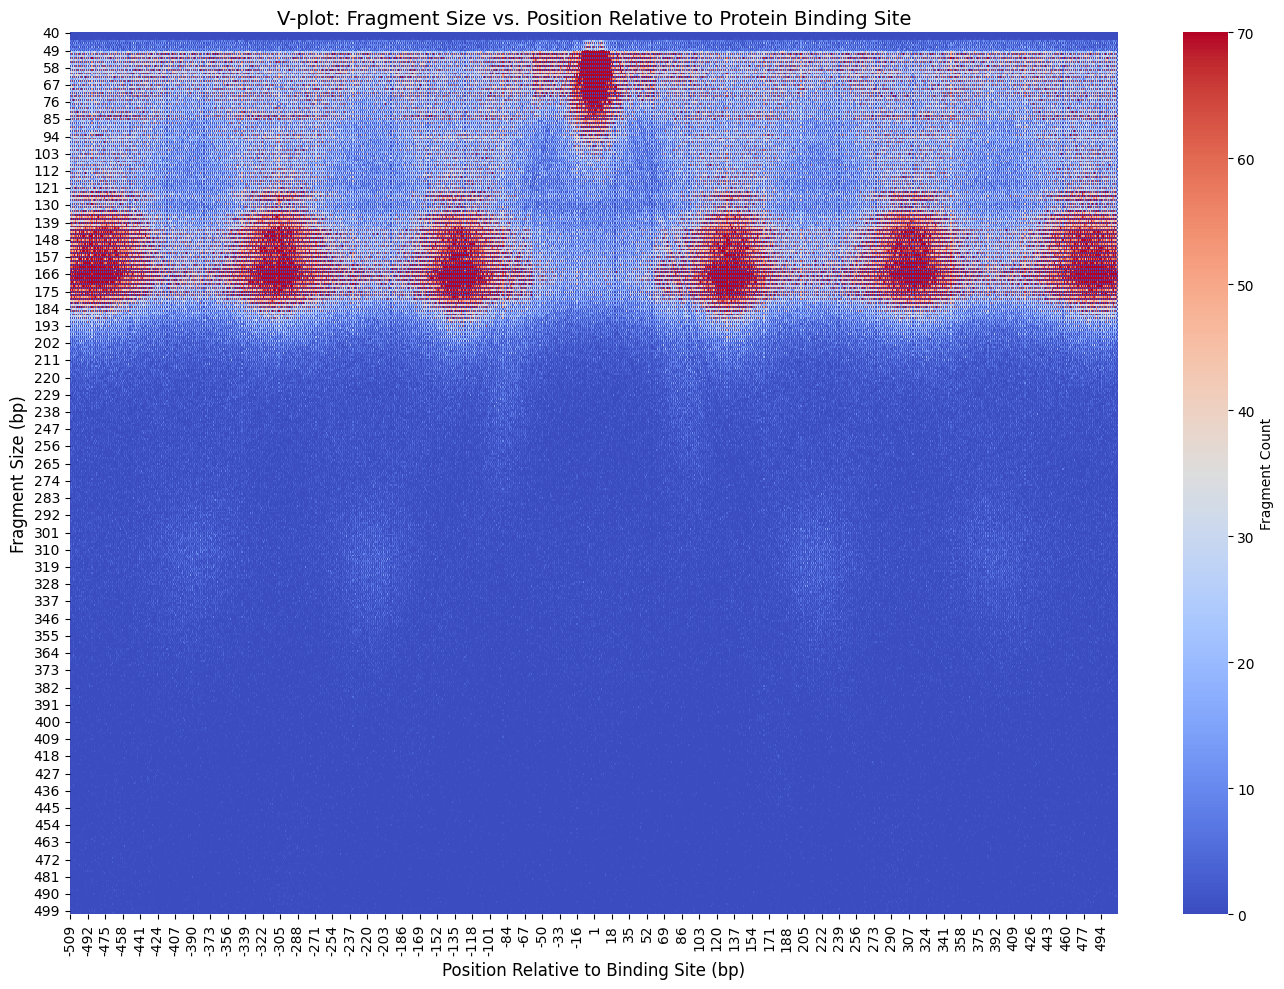

In [20]:
def create_vplot(xyz_data, output_file=None):
    """
    Generate a V-plot heatmap from XYZ data.

    Parameters:
    - xyz_data: DataFrame with columns ['X', 'Y', 'Z']
    - output_file: Optional path to save the plot as an image
    """
    heatmap_data = xyz_data.pivot_table(
        values='Z',
        index='Y',
        columns='X',
        fill_value=0
    )

    plt.figure(figsize=(14, 10))
    sns.heatmap(heatmap_data, cmap='coolwarm', robust=True)

    plt.xlabel('Position Relative to Binding Site (bp)', fontsize=12)
    plt.ylabel('Fragment Size (bp)', fontsize=12)
    plt.title('V-plot: Fragment Size vs. Position Relative to Protein Binding Site', fontsize=14)

    cbar = plt.gca().collections[0].colorbar
    cbar.set_label('Fragment Count', fontsize=10)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_file}")

    return plt

print("\nGenerating V-plot...")
vplot = create_vplot(xyz_data, output_file='v_plot.png')
plt.show()